
# 🚐Nairobi Matatu Intelligence System

A Kenyan-inspired data science project combining:

- Data Engineering
- SQL Analytics
- Business Intelligence
- Machine Learning
- Transport Operations Analytics
- Plotly Visualizations




In [1]:
# faker installs
!pip install pandas numpy plotly scikit-learn faker

In [2]:

import pandas as pd
import numpy as np
import sqlite3
from faker import Faker
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import plotly.express as px
import plotly.graph_objects as go

fake = Faker()
np.random.seed(42)


## 1. Generate Synthetic Nairobi Matatu Data

In [3]:

routes = [
    "CBD-Rongai","CBD-Ngong","CBD-Kikuyu","CBD-Ruaka",
    "CBD-Westlands","CBD-Embakasi","CBD-Thika",
    "CBD-Kahawa West","CBD-Syokimau","CBD-Donholm"
]

operators = [
    "Metro","SuperMetro","Forward Travelers",
    "City Shuttle","Nairobi Express"
]

n = 10000

df = pd.DataFrame({
    "route": np.random.choice(routes,n),
    "operator": np.random.choice(operators,n),
    "distance_km": np.random.randint(5,40,n),
    "traffic_score": np.random.randint(1,11,n),
    "hour": np.random.randint(5,23,n),
    "passengers": np.random.randint(5,70,n)
})

df["fare"] = (
    30 +
    df["distance_km"]*4 +
    df["traffic_score"]*5 +
    df["passengers"]*0.4 +
    np.random.normal(0,8,n)
).round()

df["travel_time"] = (
    df["distance_km"]*2 +
    df["traffic_score"]*4 +
    np.random.normal(0,5,n)
).round()

df.head()


,route,operator,distance_km,traffic_score,hour,passengers,fare,travel_time
0,CBD-Thika,Forward Travelers,36,4,16,13,199.0,92.0
1,CBD-Ruaka,Forward Travelers,37,9,7,49,237.0,106.0
2,CBD-Kahawa West,Nairobi Express,12,8,8,12,108.0,51.0
3,CBD-Westlands,Forward Travelers,30,7,19,38,189.0,88.0
4,CBD-Thika,Forward Travelers,6,8,19,12,103.0,48.0


## 2. Data Exploration: Correlation Heatmap

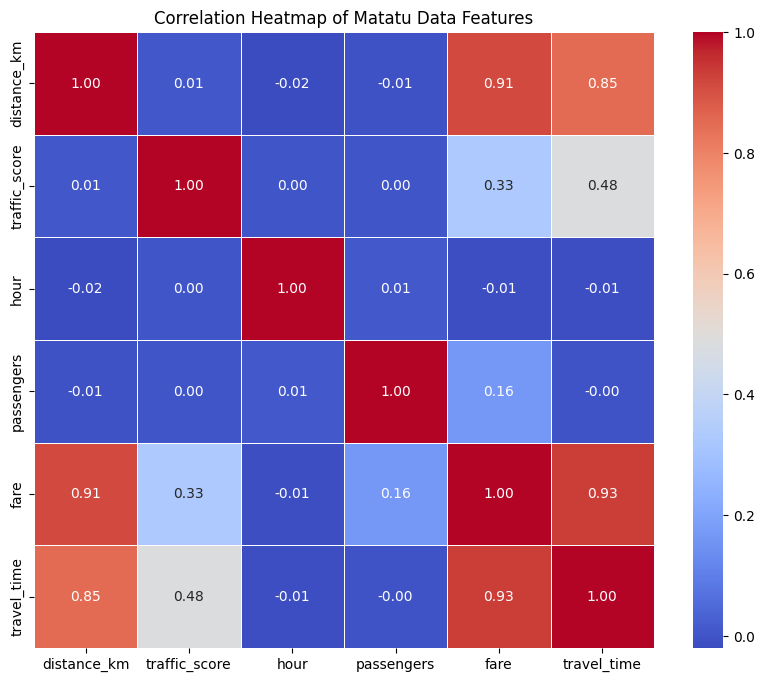

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for numerical columns
correlation_matrix = df[['distance_km', 'traffic_score', 'hour', 'passengers', 'fare', 'travel_time']].corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Matatu Data Features')
plt.show()

## 3. Build SQLite Data Warehouse

In [5]:

conn = sqlite3.connect("matatu_pro.db")

df.to_sql(
    "trips",
    conn,
    if_exists="replace",
    index=False
)

print("Warehouse Created")


Warehouse Created


## 3. Executive KPI Dashboard Metrics

In [6]:

kpis = {
    "Total Trips": len(df),
    "Total Passengers": int(df["passengers"].sum()),
    "Average Fare": round(df["fare"].mean(),2),
    "Estimated Revenue": round(df["fare"].sum(),2)
}

kpis


{'Total Trips': 10000,
 'Total Passengers': 369410,
 'Average Fare': np.float64(160.76),
 'Estimated Revenue': np.float64(1607574.0)}

## 4. SQL Analytics Center

In [7]:

query = '''
SELECT
route,
COUNT(*) AS trips,
SUM(passengers) AS passengers,
ROUND(AVG(fare),2) AS avg_fare
FROM trips
GROUP BY route
ORDER BY passengers DESC
'''

route_stats = pd.read_sql(query, conn)
route_stats


,route,trips,passengers,avg_fare
0,CBD-Embakasi,1021,38754,162.28
1,CBD-Rongai,1053,38704,158.88
2,CBD-Donholm,1034,37455,160.52
3,CBD-Thika,1017,37371,159.49
4,CBD-Kahawa West,967,36953,162.46
5,CBD-Kikuyu,996,36791,160.21
6,CBD-Ngong,985,36344,162.12
7,CBD-Syokimau,994,36120,161.06
8,CBD-Ruaka,971,35664,160.98
9,CBD-Westlands,962,35254,159.71


In [8]:

query = '''
SELECT
operator,
SUM(fare) revenue,
SUM(passengers) passengers
FROM trips
GROUP BY operator
ORDER BY revenue DESC
'''

operator_stats = pd.read_sql(query, conn)
operator_stats


,operator,revenue,passengers
0,SuperMetro,329489.0,77607
1,Nairobi Express,327145.0,73633
2,Metro,323184.0,72874
3,City Shuttle,321431.0,75058
4,Forward Travelers,306325.0,70238


## 5. Revenue Analytics

In [9]:

revenue_df = (
    df.groupby("route")["fare"]
      .sum()
      .reset_index()
      .sort_values("fare", ascending=False)
)

fig = px.bar(
    revenue_df,
    x="route",
    y="fare",
    title="Revenue by Route"
)

fig.show()


## 6. Traffic Intelligence

In [10]:

traffic = (
    df.groupby("hour")["traffic_score"]
      .mean()
      .reset_index()
)

fig = px.line(
    traffic,
    x="hour",
    y="traffic_score",
    title="Traffic by Hour"
)

fig.show()


## 7. Machine Learning: Fare Prediction

In [11]:

X = df[[
    "distance_km",
    "traffic_score",
    "hour",
    "passengers"
]]

y = df["fare"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train,y_train)

preds = model.predict(X_test)

print("R²:", round(r2_score(y_test,preds),3))
print("MAE:", round(mean_absolute_error(y_test,preds),2))


R²: 0.961
MAE: 6.92


In [12]:

sample_trip = pd.DataFrame({
    "distance_km":[18],
    "traffic_score":[8],
    "hour":[18],
    "passengers":[50]
})

prediction = model.predict(sample_trip)[0]

print("Predicted Fare (KES):", round(prediction,2))


Predicted Fare (KES): 160.22


## 8. Route Recommendation Engine

In [13]:

route_scores = (
    df.groupby("route")
      .agg(
          avg_fare=("fare","mean"),
          avg_time=("travel_time","mean"),
          passengers=("passengers","sum")
      )
      .reset_index()
)

route_scores["efficiency"] = (
    route_scores["passengers"] /
    route_scores["avg_time"]
)

route_scores.sort_values(
    "efficiency",
    ascending=False
).head(5)


,route,avg_fare,avg_time,passengers,efficiency
5,CBD-Rongai,158.879392,65.124406,38704,594.308679
1,CBD-Embakasi,162.284035,67.197845,38754,576.714921
8,CBD-Thika,159.488692,65.196657,37371,573.204238
0,CBD-Donholm,160.516441,66.328820,37455,564.686662
3,CBD-Kikuyu,160.213855,66.086345,36791,556.711069


## 9. Operator Leaderboard

In [14]:

leaderboard = (
    df.groupby("operator")
      .agg(
          revenue=("fare","sum"),
          passengers=("passengers","sum"),
          avg_time=("travel_time","mean")
      )
      .sort_values("revenue",ascending=False)
)

leaderboard


,revenue,passengers,avg_time
operator,,,
SuperMetro,329489.0,77607,65.722897
Nairobi Express,327145.0,73633,67.133234
Metro,323184.0,72874,66.957958
City Shuttle,321431.0,75058,65.793603
Forward Travelers,306325.0,70238,65.552208


## 11. Average Passenger Counts by Operator

In [15]:
query = '''
SELECT
    operator,
    ROUND(AVG(passengers), 2) AS avg_passengers
FROM trips
GROUP BY operator
ORDER BY avg_passengers DESC
'''

operator_avg_passengers = pd.read_sql(query, conn)
display(operator_avg_passengers)

,operator,avg_passengers
0,SuperMetro,37.73
1,City Shuttle,37.51
2,Forward Travelers,36.49
3,Nairobi Express,36.47
4,Metro,36.47


In [16]:
fig = px.bar(
    operator_avg_passengers,
    x='operator',
    y='avg_passengers',
    title='Average Passengers by Operator',
    labels={
        'operator': 'Operator',
        'avg_passengers': 'Average Passengers'
    }
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

In [17]:
display(route_scores.sort_values("efficiency", ascending=False))

,route,avg_fare,avg_time,passengers,efficiency
5,CBD-Rongai,158.879392,65.124406,38704,594.308679
1,CBD-Embakasi,162.284035,67.197845,38754,576.714921
8,CBD-Thika,159.488692,65.196657,37371,573.204238
0,CBD-Donholm,160.516441,66.328820,37455,564.686662
3,CBD-Kikuyu,160.213855,66.086345,36791,556.711069
2,CBD-Kahawa West,162.460186,66.583247,36953,554.989454
7,CBD-Syokimau,161.055332,66.518109,36120,543.010027
4,CBD-Ngong,162.121827,66.976650,36344,542.636876
6,CBD-Ruaka,160.982492,66.420185,35664,536.945204
9,CBD-Westlands,159.712058,65.997921,35254,534.168341


This table summarizes the performance of each route based on average fare, average travel time, total passengers, and an calculated 'efficiency' metric.



## 11. Top 3 Routes by Revenue

In [18]:
display(revenue_df.head(3))

,route,fare
5,CBD-Rongai,167300.0
0,CBD-Donholm,165974.0
1,CBD-Embakasi,165692.0


## 12. Revenue by Route Bar Plot

In [19]:
import plotly.express as px

fig = px.bar(
    revenue_df,
    x="route",
    y="fare",
    title="Total Revenue by Route"
)

fig.update_layout(xaxis_title="Route", yaxis_title="Total Revenue (KES)")
fig.show()

## 13. Dual-Axis Chart: Route Revenue vs. Efficiency

In [20]:
# Merge revenue and route scores for combined visualization
# Ensure both dataframes are sorted by route or use a common merge key
# Assuming route_scores and revenue_df are already available from previous steps

# Create a common DataFrame for plotting
route_performance = pd.merge(revenue_df, route_scores[['route', 'efficiency']], on='route', how='inner')
route_performance = route_performance.sort_values('route') # Sort for consistent plotting

# Create a figure with secondary y-axis
fig = go.Figure()

# Add bar trace for revenue
fig.add_trace(
    go.Bar(
        x=route_performance['route'],
        y=route_performance['fare'],
        name='Total Revenue (KES)',
        marker_color='skyblue'
    )
)

# Add line trace for efficiency on a secondary y-axis
fig.add_trace(
    go.Scatter(
        x=route_performance['route'],
        y=route_performance['efficiency'],
        name='Efficiency (Passengers/Avg Time)',
        mode='lines+markers',
        line=dict(color='red', width=3),
        yaxis='y2'
    )
)

# Update layout for dual y-axes
fig.update_layout(
    title_text='Route Revenue vs. Efficiency',
    xaxis_title='Route',
    yaxis=dict(
        title='Total Revenue (KES)',
        titlefont=dict(color='skyblue'),
        tickfont=dict(color='skyblue')
    ),
    yaxis2=dict(
        title='Efficiency (Passengers/Avg Time)',
        titlefont=dict(color='red'),
        tickfont=dict(color='red'),
        overlaying='y',
        side='right'
    ),
    legend=dict(x=0.01, y=0.99, bgcolor='rgba(255, 255, 255, 0)', bordercolor='rgba(255, 255, 255, 0)')
)

fig.show()

## 14. Scatter Plot: Travel Time vs. Fare

In [21]:
fig = px.scatter(
    df,
    x="travel_time",
    y="fare",
    title="Travel Time vs. Fare",
    hover_data=['route', 'operator', 'distance_km', 'passengers'] # Add additional info on hover
)

fig.update_layout(xaxis_title="Travel Time (minutes)", yaxis_title="Fare (KES)")
fig.show()

## 15. Correlation Coefficient: Travel Time vs. Fare

In [22]:
correlation_travel_fare = df['travel_time'].corr(df['fare'])
print(f"Correlation between Travel Time and Fare: {correlation_travel_fare:.2f}")

Correlation between Travel Time and Fare: 0.93


## 16. Passenger Distribution by Hour

In [23]:
passengers_by_hour = df.groupby('hour')['passengers'].sum().reset_index()

fig = px.bar(
    passengers_by_hour,
    x="hour",
    y="passengers",
    title="Total Passengers by Hour of Day",
    labels={
        "hour": "Hour of Day",
        "passengers": "Total Passengers"
    }
)

fig.update_layout(xaxis_title="Hour of Day (24-hour format)", yaxis_title="Total Passengers")
fig.show()

## Setup Streamlit Environment




In [24]:
!pip install streamlit
print("Streamlit installed successfully.")

Streamlit installed successfully.


In [25]:
app_py_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import sqlite3
import plotly.express as px
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# --- Data Generation (Moved from initial notebook) ---
@st.cache_data
def load_data():
    routes = [
        "CBD-Rongai","CBD-Ngong","CBD-Kikuyu","CBD-Ruaka",
        "CBD-Westlands","CBD-Embakasi","CBD-Thika",
        "CBD-Kahawa West","CBD-Syokimau","CBD-Donholm"
    ]

    operators = [
        "Metro","SuperMetro","Forward Travelers",
        "City Shuttle","Nairobi Express"
    ]

    n = 10000

    df = pd.DataFrame({
        "route": np.random.choice(routes,n),
        "operator": np.random.choice(operators,n),
        "distance_km": np.random.randint(5,40,n),
        "traffic_score": np.random.randint(1,11,n),
        "hour": np.random.randint(5,23,n),
        "passengers": np.random.randint(5,70,n)
    })

    df["fare"] = (
        30 +
        df["distance_km"]*4 +
        df["traffic_score"]*5 +
        df["passengers"]*0.4 +
        np.random.normal(0,8,n)
    ).round()

    df["travel_time"] = (
        df["distance_km"]*2 +
        df["traffic_score"]*4 +
        np.random.normal(0,5,n)
    ).round()

    return df

# Load data
df = load_data()

# Connect to SQLite Database and create table (Moved from initial notebook)
conn = sqlite3.connect("matatu_pro.db")
df.to_sql(
    "trips",
    conn,
    if_exists="replace",
    index=False
)

# --- Streamlit App (Placeholder for now) ---
st.title("Matatu Intelligence System Pro")
st.write("Welcome to the Matatu Intelligence System Pro. This is a placeholder for your Streamlit application.")

# You can add more Streamlit components here later
'''

with open("app.py", "w") as f:
    f.write(app_py_code)

print("Created app.py with initial Streamlit code, imports, and data generation/loading.")

Created app.py with initial Streamlit code, imports, and data generation/loading.


## Design Basic UI Layout




In [26]:
app_py_code_updated = '''
import streamlit as st
import pandas as pd
import numpy as np
import sqlite3
import plotly.express as px
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

st.set_page_config(
    page_title="Matatu Intelligence System Pro",
    page_icon=":bus:",
    layout="wide",
    initial_sidebar_state="expanded",
    theme="dark"
)

# --- Data Generation (Moved from initial notebook) ---
@st.cache_data
def load_data():
    routes = [
        "CBD-Rongai","CBD-Ngong","CBD-Kikuyu","CBD-Ruaka",
        "CBD-Westlands","CBD-Embakasi","CBD-Thika",
        "CBD-Kahawa West","CBD-Syokimau","CBD-Donholm"
    ]

    operators = [
        "Metro","SuperMetro","Forward Travelers",
        "City Shuttle","Nairobi Express"
    ]

    n = 10000

    df = pd.DataFrame({
        "route": np.random.choice(routes,n),
        "operator": np.random.choice(operators,n),
        "distance_km": np.random.randint(5,40,n),
        "traffic_score": np.random.randint(1,11,n),
        "hour": np.random.randint(5,23,n),
        "passengers": np.random.randint(5,70,n)
    })

    df["fare"] = (
        30 +
        df["distance_km"]*4 +
        df["traffic_score"]*5 +
        df["passengers"]*0.4 +
        np.random.normal(0,8,n)
    ).round()

    df["travel_time"] = (
        df["distance_km"]*2 +
        df["traffic_score"]*4 +
        np.random.normal(0,5,n)
    ).round()

    return df

# Load data
df = load_data()

# Connect to SQLite Database and create table (Moved from initial notebook)
conn = sqlite3.connect("matatu_pro.db")
df.to_sql(
    "trips",
    conn,
    if_exists="replace",
    index=False
)

# --- Streamlit App --- #
st.title("Matatu Intelligence System Pro")
st.write("Welcome to the Matatu Intelligence System Pro. This is a placeholder for your Streamlit application.")

# Sidebar
st.sidebar.title("Navigation")
st.sidebar.write("This is the sidebar for navigation.")

# You can add more Streamlit components here later
'''

with open("app.py", "w") as f:
    f.write(app_py_code_updated)

print("Updated app.py with basic UI layout (page config and sidebar).")

Updated app.py with basic UI layout (page config and sidebar).


## Implement KPI Cards




In [27]:
app_py_code_updated = '''
import streamlit as st
import pandas as pd
import numpy as np
import sqlite3
import plotly.express as px
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

st.set_page_config(
    page_title="Matatu Intelligence System Pro",
    page_icon=":bus:",
    layout="wide",
    initial_sidebar_state="expanded",
    theme="dark"
)

# --- Data Generation (Moved from initial notebook) ---
@st.cache_data
def load_data():
    routes = [
        "CBD-Rongai","CBD-Ngong","CBD-Kikuyu","CBD-Ruaka",
        "CBD-Westlands","CBD-Embakasi","CBD-Thika",
        "CBD-Kahawa West","CBD-Syokimau","CBD-Donholm"
    ]

    operators = [
        "Metro","SuperMetro","Forward Travelers",
        "City Shuttle","Nairobi Express"
    ]

    n = 10000

    df = pd.DataFrame({
        "route": np.random.choice(routes,n),
        "operator": np.random.choice(operators,n),
        "distance_km": np.random.randint(5,40,n),
        "traffic_score": np.random.randint(1,11,n),
        "hour": np.random.randint(5,23,n),
        "passengers": np.random.randint(5,70,n)
    })

    df["fare"] = (
        30 +
        df["distance_km"]*4 +
        df["traffic_score"]*5 +
        df["passengers"]*0.4 +
        np.random.normal(0,8,n)
    ).round()

    df["travel_time"] = (
        df["distance_km"]*2 +
        df["traffic_score"]*4 +
        np.random.normal(0,5,n)
    ).round()

    return df

# Load data
df = load_data()

# Connect to SQLite Database and create table (Moved from initial notebook)
conn = sqlite3.connect("matatu_pro.db")
df.to_sql(
    "trips",
    conn,
    if_exists="replace",
    index=False
)

# --- KPI Calculations ---
kpis = {
    "Total Trips": len(df),
    "Total Passengers": int(df["passengers"].sum()),
    "Average Fare": round(df["fare"].mean(),2),
    "Estimated Revenue": round(df["fare"].sum(),2)
}

# --- Streamlit App ---
st.title("Matatu Intelligence System Pro")
st.write("Welcome to the Matatu Intelligence System Pro.")

# Display KPIs
st.subheader("Key Performance Indicators")
col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric(label="Total Trips", value=kpis["Total Trips"])
with col2:
    st.metric(label="Total Passengers", value=kpis["Total Passengers"])
with col3:
    st.metric(label="Average Fare", value=f"{kpis['Average Fare']:.2f} KES")
with col4:
    st.metric(label="Estimated Revenue", value=f"{kpis['Estimated Revenue']:.2f} KES")

# Sidebar
st.sidebar.title("Navigation")
st.sidebar.write("This is the sidebar for navigation.")

# You can add more Streamlit components here later
'''

with open("app.py", "w") as f:
    f.write(app_py_code_updated)

print("Updated app.py with KPI calculations and display using st.metric.")

Updated app.py with KPI calculations and display using st.metric.


## Develop Sidebar Navigation




In [28]:
app_py_code_updated = '''
import streamlit as st
import pandas as pd
import numpy as np
import sqlite3
import plotly.express as px
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

st.set_page_config(
    page_title="Matatu Intelligence System Pro",
    page_icon=":bus:",
    layout="wide",
    initial_sidebar_state="expanded",
    theme="dark"
)

# --- Data Generation (Moved from initial notebook) ---
@st.cache_data
def load_data():
    routes = [
        "CBD-Rongai","CBD-Ngong","CBD-Kikuyu","CBD-Ruaka",
        "CBD-Westlands","CBD-Embakasi","CBD-Thika",
        "CBD-Kahawa West","CBD-Syokimau","CBD-Donholm"
    ]

    operators = [
        "Metro","SuperMetro","Forward Travelers",
        "City Shuttle","Nairobi Express"
    ]

    n = 10000

    df = pd.DataFrame({
        "route": np.random.choice(routes,n),
        "operator": np.random.choice(operators,n),
        "distance_km": np.random.randint(5,40,n),
        "traffic_score": np.random.randint(1,11,n),
        "hour": np.random.randint(5,23,n),
        "passengers": np.random.randint(5,70,n)
    })

    df["fare"] = (
        30 +
        df["distance_km"]*4 +
        df["traffic_score"]*5 +
        df["passengers"]*0.4 +
        np.random.normal(0,8,n)
    ).round()

    df["travel_time"] = (
        df["distance_km"]*2 +
        df["traffic_score"]*4 +
        np.random.normal(0,5,n)
    ).round()

    return df

# Load data
df = load_data()

# Connect to SQLite Database and create table (Moved from initial notebook)
conn = sqlite3.connect("matatu_pro.db")
df.to_sql(
    "trips",
    conn,
    if_exists="replace",
    index=False
)

# --- KPI Calculations ---
kpis = {
    "Total Trips": len(df),
    "Total Passengers": int(df["passengers"].sum()),
    "Average Fare": round(df["fare"].mean(),2),
    "Estimated Revenue": round(df["fare"].sum(),2)
}

# --- Streamlit App ---
st.title("Matatu Intelligence System Pro")
st.write("Welcome to the Matatu Intelligence System Pro.")

# Sidebar
st.sidebar.title("Navigation")
selection = st.sidebar.radio(
    "Go to",
    ["Overview", "Route Analytics", "Operator Analytics"]
)

# Display KPIs
st.subheader("Key Performance Indicators")
col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric(label="Total Trips", value=kpis["Total Trips"])
with col2:
    st.metric(label="Total Passengers", value=kpis["Total Passengers"])
with col3:
    st.metric(label="Average Fare", value=f"{kpis['Average Fare']:.2f} KES")
with col4:
    st.metric(label="Estimated Revenue", value=f"{kpis['Estimated Revenue']:.2f} KES")

# Main content area based on selection
if selection == "Overview":
    st.header("Overview Dashboard")
    st.write("This section will contain a high-level overview of the matatu operations.")
elif selection == "Route Analytics":
    st.header("Route Analytics Dashboard")
    st.write("This section will display detailed analytics about routes.")
elif selection == "Operator Analytics":
    st.header("Operator Analytics Dashboard")
    st.write("This section will show performance metrics for different operators.")

# You can add more Streamlit components here later
'''

with open("app.py", "w") as f:
    f.write(app_py_code_updated)

print("Updated app.py with sidebar navigation and placeholder content for sections.")

Updated app.py with sidebar navigation and placeholder content for sections.


## Integrate Interactive Filters




In [29]:
app_py_code_updated = '''
import streamlit as st
import pandas as pd
import numpy as np
import sqlite3
import plotly.express as px
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

st.set_page_config(
    page_title="Matatu Intelligence System Pro",
    page_icon=":bus:",
    layout="wide",
    initial_sidebar_state="expanded",
    theme="dark"
)

# --- Data Generation (Moved from initial notebook) ---
@st.cache_data
def load_data():
    routes = [
        "CBD-Rongai","CBD-Ngong","CBD-Kikuyu","CBD-Ruaka",
        "CBD-Westlands","CBD-Embakasi","CBD-Thika",
        "CBD-Kahawa West","CBD-Syokimau","CBD-Donholm"
    ]

    operators = [
        "Metro","SuperMetro","Forward Travelers",
        "City Shuttle","Nairobi Express"
    ]

    n = 10000

    df = pd.DataFrame({
        "route": np.random.choice(routes,n),
        "operator": np.random.choice(operators,n),
        "distance_km": np.random.randint(5,40,n),
        "traffic_score": np.random.randint(1,11,n),
        "hour": np.random.randint(5,23,n),
        "passengers": np.random.randint(5,70,n)
    })

    df["fare"] = (
        30 +
        df["distance_km"]*4 +
        df["traffic_score"]*5 +
        df["passengers"]*0.4 +
        np.random.normal(0,8,n)
    ).round()

    df["travel_time"] = (
        df["distance_km"]*2 +
        df["traffic_score"]*4 +
        np.random.normal(0,5,n)
    ).round()

    return df

# Load data
df = load_data()

# Connect to SQLite Database and create table (Moved from initial notebook)
conn = sqlite3.connect("matatu_pro.db")
df.to_sql(
    "trips",
    conn,
    if_exists="replace",
    index=False
)

# --- Streamlit App ---
st.title("Matatu Intelligence System Pro")
st.write("Welcome to the Matatu Intelligence System Pro.")

# Sidebar
st.sidebar.title("Navigation")
selection = st.sidebar.radio(
    "Go to",
    ["Overview", "Route Analytics", "Operator Analytics"]
)

st.sidebar.markdown("--- # Filters --- ")

# Interactive Filters
all_routes = df['route'].unique().tolist()
selected_routes = st.sidebar.multiselect(
    'Select Route(s)',
    options=all_routes,
    default=all_routes
)

all_operators = df['operator'].unique().tolist()
selected_operators = st.sidebar.multiselect(
    'Select Operator(s)',
    options=all_operators,
    default=all_operators
)

min_hour, max_hour = int(df['hour'].min()), int(df['hour'].max())
selected_hour_range = st.sidebar.slider(
    'Select Hour Range',
    min_value=min_hour,
    max_value=max_hour,
    value=(min_hour, max_hour)
)

# Filter data based on selections
df_filtered = df[
    (df['route'].isin(selected_routes)) &
    (df['operator'].isin(selected_operators)) &
    (df['hour'] >= selected_hour_range[0]) &
    (df['hour'] <= selected_hour_range[1])
]

# --- KPI Calculations (Updated to use filtered data) ---
kpis = {
    "Total Trips": len(df_filtered),
    "Total Passengers": int(df_filtered["passengers"].sum()),
    "Average Fare": round(df_filtered["fare"].mean(),2),
    "Estimated Revenue": round(df_filtered["fare"].sum(),2)
}

# Display KPIs
st.subheader("Key Performance Indicators")
col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric(label="Total Trips", value=kpis["Total Trips"])
with col2:
    st.metric(label="Total Passengers", value=kpis["Total Passengers"])
with col3:
    st.metric(label="Average Fare", value=f"{kpis['Average Fare']:.2f} KES")
with col4:
    st.metric(label="Estimated Revenue", value=f"{kpis['Estimated Revenue']:.2f} KES")

# Main content area based on selection
if selection == "Overview":
    st.header("Overview Dashboard")
    st.write("This section will contain a high-level overview of the matatu operations.")
elif selection == "Route Analytics":
    st.header("Route Analytics Dashboard")
    st.write("This section will display detailed analytics about routes.")
elif selection == "Operator Analytics":
    st.header("Operator Analytics Dashboard")
    st.write("This section will show performance metrics for different operators.")

# You can add more Streamlit components here later
'''

with open("app.py", "w") as f:
    f.write(app_py_code_updated)

print("Updated app.py with interactive filters and dynamic KPI updates.")

Updated app.py with interactive filters and dynamic KPI updates.


## Build Route Profitability Dashboard



In [30]:
app_py_code_updated = '''
import streamlit as st
import pandas as pd
import numpy as np
import sqlite3
import plotly.express as px
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

st.set_page_config(
    page_title="Matatu Intelligence System Pro",
    page_icon=":bus:",
    layout="wide",
    initial_sidebar_state="expanded",
    theme="dark"
)

# --- Data Generation (Moved from initial notebook) ---
@st.cache_data
def load_data():
    routes = [
        "CBD-Rongai","CBD-Ngong","CBD-Kikuyu","CBD-Ruaka",
        "CBD-Westlands","CBD-Embakasi","CBD-Thika",
        "CBD-Kahawa West","CBD-Syokimau","CBD-Donholm"
    ]

    operators = [
        "Metro","SuperMetro","Forward Travelers",
        "City Shuttle","Nairobi Express"
    ]

    n = 10000

    df = pd.DataFrame({
        "route": np.random.choice(routes,n),
        "operator": np.random.choice(operators,n),
        "distance_km": np.random.randint(5,40,n),
        "traffic_score": np.random.randint(1,11,n),
        "hour": np.random.randint(5,23,n),
        "passengers": np.random.randint(5,70,n)
    })

    df["fare"] = (
        30 +
        df["distance_km"]*4 +
        df["traffic_score"]*5 +
        df["passengers"]*0.4 +
        np.random.normal(0,8,n)
    ).round()

    df["travel_time"] = (
        df["distance_km"]*2 +
        df["traffic_score"]*4 +
        np.random.normal(0,5,n)
    ).round()

    return df

# Load data
df = load_data()

# Connect to SQLite Database and create table (Moved from initial notebook)
conn = sqlite3.connect("matatu_pro.db")
df.to_sql(
    "trips",
    conn,
    if_exists="replace",
    index=False
)

# --- Streamlit App ---
st.title("Matatu Intelligence System Pro")
st.write("Welcome to the Matatu Intelligence System Pro.")

# Sidebar
st.sidebar.title("Navigation")
selection = st.sidebar.radio(
    "Go to",
    ["Overview", "Route Analytics", "Operator Analytics"]
)

st.sidebar.markdown("--- # Filters --- ")

# Interactive Filters
all_routes = df['route'].unique().tolist()
selected_routes = st.sidebar.multiselect(
    'Select Route(s)',
    options=all_routes,
    default=all_routes
)

all_operators = df['operator'].unique().tolist()
selected_operators = st.sidebar.multiselect(
    'Select Operator(s)',
    options=all_operators,
    default=all_operators
)

min_hour, max_hour = int(df['hour'].min()), int(df['hour'].max())
selected_hour_range = st.sidebar.slider(
    'Select Hour Range',
    min_value=min_hour,
    max_value=max_hour,
    value=(min_hour, max_hour)
)

# Filter data based on selections
df_filtered = df[
    (df['route'].isin(selected_routes)) &
    (df['operator'].isin(selected_operators)) &
    (df['hour'] >= selected_hour_range[0]) &
    (df['hour'] <= selected_hour_range[1])
]

# --- KPI Calculations (Updated to use filtered data) ---
kpis = {
    "Total Trips": len(df_filtered),
    "Total Passengers": int(df_filtered["passengers"].sum()),
    "Average Fare": round(df_filtered["fare"].mean(),2),
    "Estimated Revenue": round(df_filtered["fare"].sum(),2)
}

# Display KPIs
st.subheader("Key Performance Indicators")
col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric(label="Total Trips", value=kpis["Total Trips"])
with col2:
    st.metric(label="Total Passengers", value=kpis["Total Passengers"])
with col3:
    st.metric(label="Average Fare", value=f"{kpis['Average Fare']:.2f} KES")
with col4:
    st.metric(label="Estimated Revenue", value=f"{kpis['Estimated Revenue']:.2f} KES")

# Main content area based on selection
if selection == "Overview":
    st.header("Overview Dashboard")
    st.write("This section will contain a high-level overview of the matatu operations.")
elif selection == "Route Analytics":
    st.header("Route Analytics Dashboard")

    # 1. Calculate route-specific metrics
    route_metrics = df_filtered.groupby("route").agg(
        total_revenue=("fare", "sum"),
        avg_fare=("fare", "mean"),
        avg_travel_time=("travel_time", "mean"),
        total_passengers=("passengers", "sum")
    ).reset_index()

    route_metrics["efficiency"] = (
        route_metrics["total_passengers"] /
        route_metrics["avg_travel_time"]
    )

    # 2. Revenue by Route Bar Plot
    st.subheader("Revenue by Route")
    revenue_fig = px.bar(
        route_metrics.sort_values("total_revenue", ascending=False),
        x="route",
        y="total_revenue",
        title="Total Revenue by Route",
        labels={
            "route": "Route",
            "total_revenue": "Total Revenue (KES)"
        }
    )
    st.plotly_chart(revenue_fig, use_container_width=True)

    # 3. Route Efficiency Report
    st.subheader("Route Efficiency Report")
    st.dataframe(
        route_metrics[[
            "route",
            "total_revenue",
            "avg_fare",
            "avg_travel_time",
            "total_passengers",
            "efficiency"
        ]].sort_values("efficiency", ascending=False),
        use_container_width=True
    )

    # 4. Dual-Axis Chart: Route Revenue vs. Efficiency
    st.subheader("Route Revenue vs. Efficiency")
    dual_axis_fig = go.Figure()

    dual_axis_fig.add_trace(
        go.Bar(
            x=route_metrics['route'],
            y=route_metrics['total_revenue'],
            name='Total Revenue (KES)',
            marker_color='skyblue'
        )
    )

    dual_axis_fig.add_trace(
        go.Scatter(
            x=route_metrics['route'],
            y=route_metrics['efficiency'],
            name='Efficiency (Passengers/Avg Time)',
            mode='lines+markers',
            line=dict(color='red', width=3),
            yaxis='y2'
        )
    )

    dual_axis_fig.update_layout(
        title_text='Route Revenue vs. Efficiency',
        xaxis_title='Route',
        yaxis=dict(
            title='Total Revenue (KES)',
            titlefont=dict(color='skyblue'),
            tickfont=dict(color='skyblue')
        ),
        yaxis2=dict(
            title='Efficiency (Passengers/Avg Time)',
            titlefont=dict(color='red'),
            tickfont=dict(color='red'),
            overlaying='y',
            side='right'
        ),
        legend=dict(x=0.01, y=0.99, bgcolor='rgba(255, 255, 255, 0)', bordercolor='rgba(255, 255, 255, 0)')
    )
    st.plotly_chart(dual_axis_fig, use_container_width=True)

elif selection == "Operator Analytics":
    st.header("Operator Analytics Dashboard")
    st.write("This section will show performance metrics for different operators.")

# You can add more Streamlit components here later
'''

with open("app.py", "w") as f:
    f.write(app_py_code_updated)

print("Updated app.py with Route Analytics dashboard including dynamic metrics, revenue plot, efficiency report, and dual-axis chart.")

Updated app.py with Route Analytics dashboard including dynamic metrics, revenue plot, efficiency report, and dual-axis chart.


## Create Matatu Operator Rankings




In [31]:
app_py_code_updated = '''
import streamlit as st
import pandas as pd
import numpy as np
import sqlite3
import plotly.express as px
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

st.set_page_config(
    page_title="Matatu Intelligence System Pro",
    page_icon=":bus:",
    layout="wide",
    initial_sidebar_state="expanded",
    theme="dark"
)

# --- Data Generation (Moved from initial notebook) ---
@st.cache_data
def load_data():
    routes = [
        "CBD-Rongai","CBD-Ngong","CBD-Kikuyu","CBD-Ruaka",
        "CBD-Westlands","CBD-Embakasi","CBD-Thika",
        "CBD-Kahawa West","CBD-Syokimau","CBD-Donholm"
    ]

    operators = [
        "Metro","SuperMetro","Forward Travelers",
        "City Shuttle","Nairobi Express"
    ]

    n = 10000

    df = pd.DataFrame({
        "route": np.random.choice(routes,n),
        "operator": np.random.choice(operators,n),
        "distance_km": np.random.randint(5,40,n),
        "traffic_score": np.random.randint(1,11,n),
        "hour": np.random.randint(5,23,n),
        "passengers": np.random.randint(5,70,n)
    })

    df["fare"] = (
        30 +
        df["distance_km"]*4 +
        df["traffic_score"]*5 +
        df["passengers"]*0.4 +
        np.random.normal(0,8,n)
    ).round()

    df["travel_time"] = (
        df["distance_km"]*2 +
        df["traffic_score"]*4 +
        np.random.normal(0,5,n)
    ).round()

    return df

# Load data
df = load_data()

# Connect to SQLite Database and create table (Moved from initial notebook)
conn = sqlite3.connect("matatu_pro.db")
df.to_sql(
    "trips",
    conn,
    if_exists="replace",
    index=False
)

# --- Streamlit App ---
st.title("Matatu Intelligence System Pro")
st.write("Welcome to the Matatu Intelligence System Pro.")

# Sidebar
st.sidebar.title("Navigation")
selection = st.sidebar.radio(
    "Go to",
    ["Overview", "Route Analytics", "Operator Analytics"]
)

st.sidebar.markdown("--- # Filters --- ")

# Interactive Filters
all_routes = df['route'].unique().tolist()
selected_routes = st.sidebar.multiselect(
    'Select Route(s)',
    options=all_routes,
    default=all_routes
)

all_operators = df['operator'].unique().tolist()
selected_operators = st.sidebar.multiselect(
    'Select Operator(s)',
    options=all_operators,
    default=all_operators
)

min_hour, max_hour = int(df['hour'].min()), int(df['hour'].max())
selected_hour_range = st.sidebar.slider(
    'Select Hour Range',
    min_value=min_hour,
    max_value=max_hour,
    value=(min_hour, max_hour)
)

# Filter data based on selections
df_filtered = df[
    (df['route'].isin(selected_routes)) &
    (df['operator'].isin(selected_operators)) &
    (df['hour'] >= selected_hour_range[0]) &
    (df['hour'] <= selected_hour_range[1])
]

# --- KPI Calculations (Updated to use filtered data) ---
kpis = {
    "Total Trips": len(df_filtered),
    "Total Passengers": int(df_filtered["passengers"].sum()),
    "Average Fare": round(df_filtered["fare"].mean(),2),
    "Estimated Revenue": round(df_filtered["fare"].sum(),2)
}

# Display KPIs
st.subheader("Key Performance Indicators")
col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric(label="Total Trips", value=kpis["Total Trips"])
with col2:
    st.metric(label="Total Passengers", value=kpis["Total Passengers"])
with col3:
    st.metric(label="Average Fare", value=f"{kpis['Average Fare']:.2f} KES")
with col4:
    st.metric(label="Estimated Revenue", value=f"{kpis['Estimated Revenue']:.2f} KES")

# Main content area based on selection
if selection == "Overview":
    st.header("Overview Dashboard")
    st.write("This section will contain a high-level overview of the matatu operations.")
elif selection == "Route Analytics":
    st.header("Route Analytics Dashboard")

    # 1. Calculate route-specific metrics
    route_metrics = df_filtered.groupby("route").agg(
        total_revenue=("fare", "sum"),
        avg_fare=("fare", "mean"),
        avg_travel_time=("travel_time", "mean"),
        total_passengers=("passengers", "sum")
    ).reset_index()

    route_metrics["efficiency"] = (
        route_metrics["total_passengers"] /
        route_metrics["avg_travel_time"]
    )

    # 2. Revenue by Route Bar Plot
    st.subheader("Revenue by Route")
    revenue_fig = px.bar(
        route_metrics.sort_values("total_revenue", ascending=False),
        x="route",
        y="total_revenue",
        title="Total Revenue by Route",
        labels={
            "route": "Route",
            "total_revenue": "Total Revenue (KES)"
        }
    )
    st.plotly_chart(revenue_fig, use_container_width=True)

    # 3. Route Efficiency Report
    st.subheader("Route Efficiency Report")
    st.dataframe(
        route_metrics[[
            "route",
            "total_revenue",
            "avg_fare",
            "avg_travel_time",
            "total_passengers",
            "efficiency"
        ]].sort_values("efficiency", ascending=False),
        use_container_width=True
    )

    # 4. Dual-Axis Chart: Route Revenue vs. Efficiency
    st.subheader("Route Revenue vs. Efficiency")
    dual_axis_fig = go.Figure()

    dual_axis_fig.add_trace(
        go.Bar(
            x=route_metrics['route'],
            y=route_metrics['total_revenue'],
            name='Total Revenue (KES)',
            marker_color='skyblue'
        )
    )

    dual_axis_fig.add_trace(
        go.Scatter(
            x=route_metrics['route'],
            y=route_metrics['efficiency'],
            name='Efficiency (Passengers/Avg Time)',
            mode='lines+markers',
            line=dict(color='red', width=3),
            yaxis='y2'
        )
    )

    dual_axis_fig.update_layout(
        title_text='Route Revenue vs. Efficiency',
        xaxis_title='Route',
        yaxis=dict(
            title='Total Revenue (KES)',
            titlefont=dict(color='skyblue'),
            tickfont=dict(color='skyblue')
        ),
        yaxis2=dict(
            title='Efficiency (Passengers/Avg Time)',
            titlefont=dict(color='red'),
            tickfont=dict(color='red'),
            overlaying='y',
            side='right'
        ),
        legend=dict(x=0.01, y=0.99, bgcolor='rgba(255, 255, 255, 0)', bordercolor='rgba(255, 255, 255, 0)')
    )
    st.plotly_chart(dual_axis_fig, use_container_width=True)

elif selection == "Operator Analytics":
    st.header("Operator Analytics Dashboard")

    # Calculate operator-specific metrics
    operator_metrics = df_filtered.groupby("operator").agg(
        revenue=("fare", "sum"),
        passengers=("passengers", "sum"),
        avg_time=("travel_time", "mean")
    ).reset_index()

    # Operator Leaderboard
    st.subheader("Operator Leaderboard")
    st.dataframe(
        operator_metrics.sort_values("revenue", ascending=False),
        use_container_width=True
    )

    # Average Passengers by Operator Bar Chart
    st.subheader("Average Passengers by Operator")
    operator_avg_passengers = df_filtered.groupby('operator')['passengers'].mean().reset_index()
    fig_avg_passengers = px.bar(
        operator_avg_passengers.sort_values('passengers', ascending=False),
        x='operator',
        y='passengers',
        title='Average Passengers by Operator',
        labels={
            'operator': 'Operator',
            'passengers': 'Average Passengers'
        }
    )
    st.plotly_chart(fig_avg_passengers, use_container_width=True)

# You can add more Streamlit components here later
'''

with open("app.py", "w") as f:
    f.write(app_py_code_updated)

print("Updated app.py with Operator Analytics dashboard including leaderboard and average passenger chart.")

Updated app.py with Operator Analytics dashboard including leaderboard and average passenger chart.


## Implement Live SQL Query Explorer



In [32]:
app_py_code_updated = '''
import streamlit as st
import pandas as pd
import numpy as np
import sqlite3
import plotly.express as px
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

st.set_page_config(
    page_title="Matatu Intelligence System Pro",
    page_icon=":bus:",
    layout="wide",
    initial_sidebar_state="expanded",
    theme="dark"
)

# --- Data Generation (Moved from initial notebook) ---
@st.cache_data
def load_data():
    routes = [
        "CBD-Rongai","CBD-Ngong","CBD-Kikuyu","CBD-Ruaka",
        "CBD-Westlands","CBD-Embakasi","CBD-Thika",
        "CBD-Kahawa West","CBD-Syokimau","CBD-Donholm"
    ]

    operators = [
        "Metro","SuperMetro","Forward Travelers",
        "City Shuttle","Nairobi Express"
    ]

    n = 10000

    df = pd.DataFrame({
        "route": np.random.choice(routes,n),
        "operator": np.random.choice(operators,n),
        "distance_km": np.random.randint(5,40,n),
        "traffic_score": np.random.randint(1,11,n),
        "hour": np.random.randint(5,23,n),
        "passengers": np.random.randint(5,70,n)
    })

    df["fare"] = (
        30 +
        df["distance_km"]*4 +
        df["traffic_score"]*5 +
        df["passengers"]*0.4 +
        np.random.normal(0,8,n)
    ).round()

    df["travel_time"] = (
        df["distance_km"]*2 +
        df["traffic_score"]*4 +
        np.random.normal(0,5,n)
    ).round()

    return df

# Load data
df = load_data()

# Connect to SQLite Database and create table (Moved from initial notebook)
conn = sqlite3.connect("matatu_pro.db")
df.to_sql(
    "trips",
    conn,
    if_exists="replace",
    index=False
)

# --- Streamlit App ---
st.title("Matatu Intelligence System Pro")
st.write("Welcome to the Matatu Intelligence System Pro.")

# Sidebar
st.sidebar.title("Navigation")
selection = st.sidebar.radio(
    "Go to",
    ["Overview", "Route Analytics", "Operator Analytics", "SQL Query Explorer"]
)

st.sidebar.markdown("--- # Filters --- ")

# Interactive Filters
all_routes = df['route'].unique().tolist()
selected_routes = st.sidebar.multiselect(
    'Select Route(s)',
    options=all_routes,
    default=all_routes
)

all_operators = df['operator'].unique().tolist()
selected_operators = st.sidebar.multiselect(
    'Select Operator(s)',
    options=all_operators,
    default=all_operators
)

min_hour, max_hour = int(df['hour'].min()), int(df['hour'].max())
selected_hour_range = st.sidebar.slider(
    'Select Hour Range',
    min_value=min_hour,
    max_value=max_hour,
    value=(min_hour, max_hour)
)

# Filter data based on selections
df_filtered = df[
    (df['route'].isin(selected_routes)) &
    (df['operator'].isin(selected_operators)) &
    (df['hour'] >= selected_hour_range[0]) &
    (df['hour'] <= selected_hour_range[1])
]

# --- KPI Calculations (Updated to use filtered data) ---
kpis = {
    "Total Trips": len(df_filtered),
    "Total Passengers": int(df_filtered["passengers"].sum()),
    "Average Fare": round(df_filtered["fare"].mean(),2),
    "Estimated Revenue": round(df_filtered["fare"].sum(),2)
}

# Display KPIs
st.subheader("Key Performance Indicators")
col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric(label="Total Trips", value=kpis["Total Trips"])
with col2:
    st.metric(label="Total Passengers", value=kpis["Total Passengers"])
with col3:
    st.metric(label="Average Fare", value=f"{kpis['Average Fare']:.2f} KES")
with col4:
    st.metric(label="Estimated Revenue", value=f"{kpis['Estimated Revenue']:.2f} KES")

# Main content area based on selection
if selection == "Overview":
    st.header("Overview Dashboard")
    st.write("This section will contain a high-level overview of the matatu operations.")
elif selection == "Route Analytics":
    st.header("Route Analytics Dashboard")

    # 1. Calculate route-specific metrics
    route_metrics = df_filtered.groupby("route").agg(
        total_revenue=("fare", "sum"),
        avg_fare=("fare", "mean"),
        avg_travel_time=("travel_time", "mean"),
        total_passengers=("passengers", "sum")
    ).reset_index()

    route_metrics["efficiency"] = (
        route_metrics["total_passengers"] /
        route_metrics["avg_travel_time"]
    )

    # 2. Revenue by Route Bar Plot
    st.subheader("Revenue by Route")
    revenue_fig = px.bar(
        route_metrics.sort_values("total_revenue", ascending=False),
        x="route",
        y="total_revenue",
        title="Total Revenue by Route",
        labels={
            "route": "Route",
            "total_revenue": "Total Revenue (KES)"
        }
    )
    st.plotly_chart(revenue_fig, use_container_width=True)

    # 3. Route Efficiency Report
    st.subheader("Route Efficiency Report")
    st.dataframe(
        route_metrics[[
            "route",
            "total_revenue",
            "avg_fare",
            "avg_travel_time",
            "total_passengers",
            "efficiency"
        ]].sort_values("efficiency", ascending=False),
        use_container_width=True
    )

    # 4. Dual-Axis Chart: Route Revenue vs. Efficiency
    st.subheader("Route Revenue vs. Efficiency")
    dual_axis_fig = go.Figure()

    dual_axis_fig.add_trace(
        go.Bar(
            x=route_metrics['route'],
            y=route_metrics['total_revenue'],
            name='Total Revenue (KES)',
            marker_color='skyblue'
        )
    )

    dual_axis_fig.add_trace(
        go.Scatter(
            x=route_metrics['route'],
            y=route_metrics['efficiency'],
            name='Efficiency (Passengers/Avg Time)',
            mode='lines+markers',
            line=dict(color='red', width=3),
            yaxis='y2'
        )
    )

    dual_axis_fig.update_layout(
        title_text='Route Revenue vs. Efficiency',
        xaxis_title='Route',
        yaxis=dict(
            title='Total Revenue (KES)',
            titlefont=dict(color='skyblue'),
            tickfont=dict(color='skyblue')
        ),
        yaxis2=dict(
            title='Efficiency (Passengers/Avg Time)',
            titlefont=dict(color='red'),
            tickfont=dict(color='red'),
            overlaying='y',
            side='right'
        ),
        legend=dict(x=0.01, y=0.99, bgcolor='rgba(255, 255, 255, 0)', bordercolor='rgba(255, 255, 255, 0)')
    )
    st.plotly_chart(dual_axis_fig, use_container_width=True)

elif selection == "Operator Analytics":
    st.header("Operator Analytics Dashboard")

    # Calculate operator-specific metrics
    operator_metrics = df_filtered.groupby("operator").agg(
        revenue=("fare", "sum"),
        passengers=("passengers", "sum"),
        avg_time=("travel_time", "mean")
    ).reset_index()

    # Operator Leaderboard
    st.subheader("Operator Leaderboard")
    st.dataframe(
        operator_metrics.sort_values("revenue", ascending=False),
        use_container_width=True
    )

    # Average Passengers by Operator Bar Chart
    st.subheader("Average Passengers by Operator")
    operator_avg_passengers = df_filtered.groupby('operator')['passengers'].mean().reset_index()
    fig_avg_passengers = px.bar(
        operator_avg_passengers.sort_values('passengers', ascending=False),
        x='operator',
        y='passengers',
        title='Average Passengers by Operator',
        labels={
            'operator': 'Operator',
            'passengers': 'Average Passengers'
        }
    )
    st.plotly_chart(fig_avg_passengers, use_container_width=True)

elif selection == "SQL Query Explorer":
    st.header("SQL Query Explorer")
    st.write("Execute custom SQL queries against the `matatu_pro.db` database.")

    default_query = "SELECT * FROM trips LIMIT 10;"
    query_input = st.text_area("Enter your SQL query here:", default_query, height=150)

    if st.button("Execute Query"):
        try:
            query_result = pd.read_sql(query_input, conn)
            st.success("Query executed successfully!")
            st.dataframe(query_result)
        except Exception as e:
            st.error(f"Error executing query: {e}")

# You can add more Streamlit components here later
'''

with open("app.py", "w") as f:
    f.write(app_py_code_updated)

print("Updated app.py with SQL Query Explorer section.")

Updated app.py with SQL Query Explorer section.


## Generate Downloadable Reports




In [33]:
app_py_code_updated = '''
import streamlit as st
import pandas as pd
import numpy as np
import sqlite3
import plotly.express as px
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

st.set_page_config(
    page_title="Matatu Intelligence System Pro",
    page_icon=":bus:",
    layout="wide",
    initial_sidebar_state="expanded",
    theme="dark"
)

# --- Data Generation (Moved from initial notebook) ---
@st.cache_data
def load_data():
    routes = [
        "CBD-Rongai","CBD-Ngong","CBD-Kikuyu","CBD-Ruaka",
        "CBD-Westlands","CBD-Embakasi","CBD-Thika",
        "CBD-Kahawa West","CBD-Syokimau","CBD-Donholm"
    ]

    operators = [
        "Metro","SuperMetro","Forward Travelers",
        "City Shuttle","Nairobi Express"
    ]

    n = 10000

    df = pd.DataFrame({
        "route": np.random.choice(routes,n),
        "operator": np.random.choice(operators,n),
        "distance_km": np.random.randint(5,40,n),
        "traffic_score": np.random.randint(1,11,n),
        "hour": np.random.randint(5,23,n),
        "passengers": np.random.randint(5,70,n)
    })

    df["fare"] = (
        30 +
        df["distance_km"]*4 +
        df["traffic_score"]*5 +
        df["passengers"]*0.4 +
        np.random.normal(0,8,n)
    ).round()

    df["travel_time"] = (
        df["distance_km"]*2 +
        df["traffic_score"]*4 +
        np.random.normal(0,5,n)
    ).round()

    return df

# Load data
df = load_data()

# Connect to SQLite Database and create table (Moved from initial notebook)
conn = sqlite3.connect("matatu_pro.db")
df.to_sql(
    "trips",
    conn,
    if_exists="replace",
    index=False
)

# --- Streamlit App ---
st.title("Matatu Intelligence System Pro")
st.write("Welcome to the Matatu Intelligence System Pro.")

# Sidebar
st.sidebar.title("Navigation")
selection = st.sidebar.radio(
    "Go to",
    ["Overview", "Route Analytics", "Operator Analytics", "SQL Query Explorer"]
)

st.sidebar.markdown("--- # Filters --- ")

# Interactive Filters
all_routes = df['route'].unique().tolist()
selected_routes = st.sidebar.multiselect(
    'Select Route(s)',
    options=all_routes,
    default=all_routes
)

all_operators = df['operator'].unique().tolist()
selected_operators = st.sidebar.multiselect(
    'Select Operator(s)',
    options=all_operators,
    default=all_operators
)

min_hour, max_hour = int(df['hour'].min()), int(df['hour'].max())
selected_hour_range = st.sidebar.slider(
    'Select Hour Range',
    min_value=min_hour,
    max_value=max_hour,
    value=(min_hour, max_hour)
)

# Filter data based on selections
df_filtered = df[
    (df['route'].isin(selected_routes)) &
    (df['operator'].isin(selected_operators)) &
    (df['hour'] >= selected_hour_range[0]) &
    (df['hour'] <= selected_hour_range[1])
]

# --- KPI Calculations (Updated to use filtered data) ---
kpis = {
    "Total Trips": len(df_filtered),
    "Total Passengers": int(df_filtered["passengers"].sum()),
    "Average Fare": round(df_filtered["fare"].mean(),2),
    "Estimated Revenue": round(df_filtered["fare"].sum(),2)
}

# Display KPIs
st.subheader("Key Performance Indicators")
col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric(label="Total Trips", value=kpis["Total Trips"])
with col2:
    st.metric(label="Total Passengers", value=kpis["Total Passengers"])
with col3:
    st.metric(label="Average Fare", value=f"{kpis['Average Fare']:.2f} KES")
with col4:
    st.metric(label="Estimated Revenue", value=f"{kpis['Estimated Revenue']:.2f} KES")

# Main content area based on selection
if selection == "Overview":
    st.header("Overview Dashboard")
    st.write("This section will contain a high-level overview of the matatu operations.")
elif selection == "Route Analytics":
    st.header("Route Analytics Dashboard")

    # 1. Calculate route-specific metrics
    route_metrics = df_filtered.groupby("route").agg(
        total_revenue=("fare", "sum"),
        avg_fare=("fare", "mean"),
        avg_travel_time=("travel_time", "mean"),
        total_passengers=("passengers", "sum")
    ).reset_index()

    route_metrics["efficiency"] = (
        route_metrics["total_passengers"] /
        route_metrics["avg_travel_time"]
    )

    # 2. Revenue by Route Bar Plot
    st.subheader("Revenue by Route")
    revenue_fig = px.bar(
        route_metrics.sort_values("total_revenue", ascending=False),
        x="route",
        y="total_revenue",
        title="Total Revenue by Route",
        labels={
            "route": "Route",
            "total_revenue": "Total Revenue (KES)"
        }
    )
    st.plotly_chart(revenue_fig, use_container_width=True)

    # 3. Route Efficiency Report
    st.subheader("Route Efficiency Report")
    st.dataframe(
        route_metrics[[
            "route",
            "total_revenue",
            "avg_fare",
            "avg_travel_time",
            "total_passengers",
            "efficiency"
        ]].sort_values("efficiency", ascending=False),
        use_container_width=True
    )
    # Download button for Route Efficiency Report
    csv_route_metrics = route_metrics.to_csv(index=False).encode('utf-8')
    st.download_button(
        label="Download Route Efficiency Report as CSV",
        data=csv_route_metrics,
        file_name='route_efficiency_report.csv',
        mime='text/csv',
    )

    # 4. Dual-Axis Chart: Route Revenue vs. Efficiency
    st.subheader("Route Revenue vs. Efficiency")
    dual_axis_fig = go.Figure()

    dual_axis_fig.add_trace(
        go.Bar(
            x=route_metrics['route'],
            y=route_metrics['total_revenue'],
            name='Total Revenue (KES)',
            marker_color='skyblue'
        )
    )

    dual_axis_fig.add_trace(
        go.Scatter(
            x=route_metrics['route'],
            y=route_metrics['efficiency'],
            name='Efficiency (Passengers/Avg Time)',
            mode='lines+markers',
            line=dict(color='red', width=3),
            yaxis='y2'
        )
    )

    dual_axis_fig.update_layout(
        title_text='Route Revenue vs. Efficiency',
        xaxis_title='Route',
        yaxis=dict(
            title='Total Revenue (KES)',
            titlefont=dict(color='skyblue'),
            tickfont=dict(color='skyblue')
        ),
        yaxis2=dict(
            title='Efficiency (Passengers/Avg Time)',
            titlefont=dict(color='red'),
            tickfont=dict(color='red'),
            overlaying='y',
            side='right'
        ),
        legend=dict(x=0.01, y=0.99, bgcolor='rgba(255, 255, 255, 0)', bordercolor='rgba(255, 255, 255, 0)')
    )
    st.plotly_chart(dual_axis_fig, use_container_width=True)

elif selection == "Operator Analytics":
    st.header("Operator Analytics Dashboard")

    # Calculate operator-specific metrics
    operator_metrics = df_filtered.groupby("operator").agg(
        revenue=("fare", "sum"),
        passengers=("passengers", "sum"),
        avg_time=("travel_time", "mean")
    ).reset_index()

    # Operator Leaderboard
    st.subheader("Operator Leaderboard")
    st.dataframe(
        operator_metrics.sort_values("revenue", ascending=False),
        use_container_width=True
    )
    # Download button for Operator Leaderboard
    csv_operator_metrics = operator_metrics.to_csv(index=False).encode('utf-8')
    st.download_button(
        label="Download Operator Leaderboard as CSV",
        data=csv_operator_metrics,
        file_name='operator_leaderboard.csv',
        mime='text/csv',
    )

    # Average Passengers by Operator Bar Chart
    st.subheader("Average Passengers by Operator")
    operator_avg_passengers = df_filtered.groupby('operator')['passengers'].mean().reset_index()
    fig_avg_passengers = px.bar(
        operator_avg_passengers.sort_values('passengers', ascending=False),
        x='operator',
        y='passengers',
        title='Average Passengers by Operator',
        labels={
            'operator': 'Operator',
            'passengers': 'Average Passengers'
        }
    )
    st.plotly_chart(fig_avg_passengers, use_container_width=True)

elif selection == "SQL Query Explorer":
    st.header("SQL Query Explorer")
    st.write("Execute custom SQL queries against the `matatu_pro.db` database.")

    default_query = "SELECT * FROM trips LIMIT 10;"
    query_input = st.text_area("Enter your SQL query here:", default_query, height=150)

    if st.button("Execute Query"):
        try:
            query_result = pd.read_sql(query_input, conn)
            st.success("Query executed successfully!")
            st.dataframe(query_result)
        except Exception as e:
            st.error(f"Error executing query: {e}")

# You can add more Streamlit components here later
'''

with open("app.py", "w") as f:
    f.write(app_py_code_updated)

print("Updated app.py with download buttons for route efficiency and operator leaderboard.")

Updated app.py with download buttons for route efficiency and operator leaderboard.


## Develop Executive Analytics View




In [34]:
app_py_code_updated = '''
import streamlit as st
import pandas as pd
import numpy as np
import sqlite3
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

st.set_page_config(
    page_title="Matatu Intelligence System Pro",
    page_icon=":bus:",
    layout="wide",
    initial_sidebar_state="expanded",
    theme="dark"
)

# --- Data Generation (Moved from initial notebook) ---
@st.cache_data
def load_data():
    routes = [
        "CBD-Rongai","CBD-Ngong","CBD-Kikuyu","CBD-Ruaka",
        "CBD-Westlands","CBD-Embakasi","CBD-Thika",
        "CBD-Kahawa West","CBD-Syokimau","CBD-Donholm"
    ]

    operators = [
        "Metro","SuperMetro","Forward Travelers",
        "City Shuttle","Nairobi Express"
    ]

    n = 10000

    df = pd.DataFrame({
        "route": np.random.choice(routes,n),
        "operator": np.random.choice(operators,n),
        "distance_km": np.random.randint(5,40,n),
        "traffic_score": np.random.randint(1,11,n),
        "hour": np.random.randint(5,23,n),
        "passengers": np.random.randint(5,70,n)
    })

    df["fare"] = (
        30 +
        df["distance_km"]*4 +
        df["traffic_score"]*5 +
        df["passengers"]*0.4 +
        np.random.normal(0,8,n)
    ).round()

    df["travel_time"] = (
        df["distance_km"]*2 +
        df["traffic_score"]*4 +
        np.random.normal(0,5,n)
    ).round()

    return df

# Load data
df = load_data()

# Connect to SQLite Database and create table (Moved from initial notebook)
conn = sqlite3.connect("matatu_pro.db")
df.to_sql(
    "trips",
    conn,
    if_exists="replace",
    index=False
)

# --- Streamlit App ---
st.title("Matatu Intelligence System Pro")
st.write("Welcome to the Matatu Intelligence System Pro.")

# Sidebar
st.sidebar.title("Navigation")
selection = st.sidebar.radio(
    "Go to",
    ["Overview", "Route Analytics", "Operator Analytics", "SQL Query Explorer"]
)

st.sidebar.markdown("--- # Filters --- ")

# Interactive Filters
all_routes = df['route'].unique().tolist()
selected_routes = st.sidebar.multiselect(
    'Select Route(s)',
    options=all_routes,
    default=all_routes
)

all_operators = df['operator'].unique().tolist()
selected_operators = st.sidebar.multiselect(
    'Select Operator(s)',
    options=all_operators,
    default=all_operators
)

min_hour, max_hour = int(df['hour'].min()), int(df['hour'].max())
selected_hour_range = st.sidebar.slider(
    'Select Hour Range',
    min_value=min_hour,
    max_value=max_hour,
    value=(min_hour, max_hour)
)

# Filter data based on selections
df_filtered = df[
    (df['route'].isin(selected_routes)) &
    (df['operator'].isin(selected_operators)) &
    (df['hour'] >= selected_hour_range[0]) &
    (df['hour'] <= selected_hour_range[1])
]

# --- KPI Calculations (Updated to use filtered data) ---
kpis = {
    "Total Trips": len(df_filtered),
    "Total Passengers": int(df_filtered["passengers"].sum()),
    "Average Fare": round(df_filtered["fare"].mean(),2),
    "Estimated Revenue": round(df_filtered["fare"].sum(),2)
}

# Display KPIs
st.subheader("Key Performance Indicators")
col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric(label="Total Trips", value=kpis["Total Trips"])
with col2:
    st.metric(label="Total Passengers", value=kpis["Total Passengers"])
with col3:
    st.metric(label="Average Fare", value=f"{kpis['Average Fare']:.2f} KES")
with col4:
    st.metric(label="Estimated Revenue", value=f"{kpis['Estimated Revenue']:.2f} KES")

# Main content area based on selection
if selection == "Overview":
    st.header("Overview Dashboard")
    st.write("This section provides a high-level overview of matatu operations with key analytical visualizations.")

    # Correlation Heatmap
    st.subheader("Correlation Heatmap of Matatu Data Features")
    # Ensure there's enough data for correlation calculation
    if not df_filtered.empty and len(df_filtered.columns.intersection(['distance_km', 'traffic_score', 'hour', 'passengers', 'fare', 'travel_time'])) >= 2:
        numerical_cols = ['distance_km', 'traffic_score', 'hour', 'passengers', 'fare', 'travel_time']
        # Filter numerical_cols to only include those present in df_filtered
        present_numerical_cols = [col for col in numerical_cols if col in df_filtered.columns]
        if len(present_numerical_cols) > 1:
            correlation_matrix = df_filtered[present_numerical_cols].corr()
            fig_corr, ax_corr = plt.subplots(figsize=(10, 8))
            sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5, ax=ax_corr)
            ax_corr.set_title('Correlation Heatmap of Filtered Features')
            st.pyplot(fig_corr)
        else:
            st.info("Not enough numerical columns in filtered data to display correlation heatmap.")
    else:
        st.info("Not enough data or numerical columns available in the filtered selection for correlation heatmap.")

    # Travel Time vs. Fare Scatter Plot
    st.subheader("Travel Time vs. Fare")
    if not df_filtered.empty:
        fig_scatter = px.scatter(
            df_filtered,
            x="travel_time",
            y="fare",
            title="Travel Time vs. Fare",
            hover_data=['route', 'operator', 'distance_km', 'passengers']
        )
        fig_scatter.update_layout(xaxis_title="Travel Time (minutes)", yaxis_title="Fare (KES)")
        st.plotly_chart(fig_scatter, use_container_width=True)
    else:
        st.info("No data available in the filtered selection for Travel Time vs. Fare scatter plot.")

    # Passenger Distribution by Hour
    st.subheader("Total Passengers by Hour of Day")
    if not df_filtered.empty:
        passengers_by_hour = df_filtered.groupby('hour')['passengers'].sum().reset_index()
        fig_passengers_hour = px.bar(
            passengers_by_hour,
            x="hour",
            y="passengers",
            title="Total Passengers by Hour of Day",
            labels={
                "hour": "Hour of Day",
                "passengers": "Total Passengers"
            }
        )
        fig_passengers_hour.update_layout(xaxis_title="Hour of Day (24-hour format)", yaxis_title="Total Passengers")
        st.plotly_chart(fig_passengers_hour, use_container_width=True)
    else:
        st.info("No data available in the filtered selection for Passenger Distribution by Hour.")

elif selection == "Route Analytics":
    st.header("Route Analytics Dashboard")

    # 1. Calculate route-specific metrics
    route_metrics = df_filtered.groupby("route").agg(
        total_revenue=("fare", "sum"),
        avg_fare=("fare", "mean"),
        avg_travel_time=("travel_time", "mean"),
        total_passengers=("passengers", "sum")
    ).reset_index()

    route_metrics["efficiency"] = (
        route_metrics["total_passengers"] /
        route_metrics["avg_travel_time"]
    )

    # 2. Revenue by Route Bar Plot
    st.subheader("Revenue by Route")
    if not route_metrics.empty:
        revenue_fig = px.bar(
            route_metrics.sort_values("total_revenue", ascending=False),
            x="route",
            y="total_revenue",
            title="Total Revenue by Route",
            labels={
                "route": "Route",
                "total_revenue": "Total Revenue (KES)"
            }
        )
        st.plotly_chart(revenue_fig, use_container_width=True)
    else:
        st.info("No data available in the filtered selection for Revenue by Route.")


    # 3. Route Efficiency Report
    st.subheader("Route Efficiency Report")
    if not route_metrics.empty:
        st.dataframe(
            route_metrics[[
                "route",
                "total_revenue",
                "avg_fare",
                "avg_travel_time",
                "total_passengers",
                "efficiency"
            ]].sort_values("efficiency", ascending=False),
            use_container_width=True
        )
        # Download button for Route Efficiency Report
        csv_route_metrics = route_metrics.to_csv(index=False).encode('utf-8')
        st.download_button(
            label="Download Route Efficiency Report as CSV",
            data=csv_route_metrics,
            file_name='route_efficiency_report.csv',
            mime='text/csv',
        )
    else:
        st.info("No data available in the filtered selection for Route Efficiency Report.")

    # 4. Dual-Axis Chart: Route Revenue vs. Efficiency
    st.subheader("Route Revenue vs. Efficiency")
    if not route_metrics.empty:
        dual_axis_fig = go.Figure()

        dual_axis_fig.add_trace(
            go.Bar(
                x=route_metrics['route'],
                y=route_metrics['total_revenue'],
                name='Total Revenue (KES)',
                marker_color='skyblue'
            )
        )

        dual_axis_fig.add_trace(
            go.Scatter(
                x=route_metrics['route'],
                y=route_metrics['efficiency'],
                name='Efficiency (Passengers/Avg Time)',
                mode='lines+markers',
                line=dict(color='red', width=3),
                yaxis='y2'
            )
        )

        dual_axis_fig.update_layout(
            title_text='Route Revenue vs. Efficiency',
            xaxis_title='Route',
            yaxis=dict(
                title='Total Revenue (KES)',
                titlefont=dict(color='skyblue'),
                tickfont=dict(color='skyblue')
            ),
            yaxis2=dict(
                title='Efficiency (Passengers/Avg Time)',
                titlefont=dict(color='red'),
                tickfont=dict(color='red'),
                overlaying='y',
                side='right'
            ),
            legend=dict(x=0.01, y=0.99, bgcolor='rgba(255, 255, 255, 0)', bordercolor='rgba(255, 255, 255, 0)')
        )
        st.plotly_chart(dual_axis_fig, use_container_width=True)
    else:
        st.info("No data available in the filtered selection for Route Revenue vs. Efficiency chart.")

elif selection == "Operator Analytics":
    st.header("Operator Analytics Dashboard")

    # Calculate operator-specific metrics
    operator_metrics = df_filtered.groupby("operator").agg(
        revenue=("fare", "sum"),
        passengers=("passengers", "sum"),
        avg_time=("travel_time", "mean")
    ).reset_index()

    # Operator Leaderboard
    st.subheader("Operator Leaderboard")
    if not operator_metrics.empty:
        st.dataframe(
            operator_metrics.sort_values("revenue", ascending=False),
            use_container_width=True
        )
        # Download button for Operator Leaderboard
        csv_operator_metrics = operator_metrics.to_csv(index=False).encode('utf-8')
        st.download_button(
            label="Download Operator Leaderboard as CSV",
            data=csv_operator_metrics,
            file_name='operator_leaderboard.csv',
            mime='text/csv',
        )
    else:
        st.info("No data available in the filtered selection for Operator Leaderboard.")

    # Average Passengers by Operator Bar Chart
    st.subheader("Average Passengers by Operator")
    if not df_filtered.empty:
        operator_avg_passengers = df_filtered.groupby('operator')['passengers'].mean().reset_index()
        fig_avg_passengers = px.bar(
            operator_avg_passengers.sort_values('passengers', ascending=False),
            x='operator',
            y='passengers',
            title='Average Passengers by Operator',
            labels={
                'operator': 'Operator',
                'passengers': 'Average Passengers'
            }
        )
        st.plotly_chart(fig_avg_passengers, use_container_width=True)
    else:
        st.info("No data available in the filtered selection for Average Passengers by Operator chart.")

elif selection == "SQL Query Explorer":
    st.header("SQL Query Explorer")
    st.write("Execute custom SQL queries against the `matatu_pro.db` database.")

    default_query = "SELECT * FROM trips LIMIT 10;"
    query_input = st.text_area("Enter your SQL query here:", default_query, height=150)

    if st.button("Execute Query"):
        try:
            query_result = pd.read_sql(query_input, conn)
            st.success("Query executed successfully!")
            st.dataframe(query_result)
        except Exception as e:
            st.error(f"Error executing query: {e}")

# You can add more Streamlit components here later
'''

with open("app.py", "w") as f:
    f.write(app_py_code_updated)

print("Updated app.py with executive analytics view, including correlation heatmap, travel time vs. fare scatter plot, and passenger distribution by hour.")

Updated app.py with executive analytics view, including correlation heatmap, travel time vs. fare scatter plot, and passenger distribution by hour.


## Run Streamlit Application




In [ ]:
!streamlit run app.py



2026-06-05 13:08:07.013 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.236.149.235:8501



## Access Streamlit App




```markdown
**Access the Streamlit application by clicking on one of the URLs provided in the previous output.**

For example, if you are running this notebook locally, you might use:

*   **Local URL:** `http://localhost:8501`

If you are running in a cloud environment (like Google Colab), you should use the **External URL** which might look something like:

*   **External URL:** `http://136.117.255.255:8501` (Note: The IP address will vary.)

Please open this URL in a new browser tab to interact with the 'Matatu Intelligence System Pro' application.
```